In [ ]:
# Create Data Folder

import os, shutil

os.makedirs("Car_price_regression_autoML", exist_ok=True)
print("Folder created")

Folder created


In [ ]:
!pip uninstall -y cudf pycaret
!pip install pycaret --q

Found existing installation: pycaret 3.3.2
Uninstalling pycaret-3.3.2:
  Successfully uninstalled pycaret-3.3.2


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Data Ingestion

# Specify the target directory within the writable file system
target_dir = "Car_price_regression_autoML"

# Download latest version directly to the target directory
!kaggle datasets download -d therohithanand/used-car-price-prediction

shutil.move("used-car-price-prediction.zip", target_dir)
shutil.unpack_archive(os.path.join(target_dir, "used-car-price-prediction.zip"), target_dir)

print("Path to dataset files:", target_dir)

Dataset URL: https://www.kaggle.com/datasets/therohithanand/used-car-price-prediction
License(s): CC-BY-SA-4.0
  0% 0.00/141k [00:00<?, ?B/s]
100% 141k/141k [00:00<00:00, 207MB/s]
Path to dataset files: Car_price_regression_autoML


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read dataset

df = pd.read_csv("/content/Car_price_regression_autoML/used_car_price_dataset_extended.csv")
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [ ]:
# Fill the null values in service_history for better visualization

values = {"service_history":"None"}

df.fillna(value = values, inplace=True)

In [ ]:
# Car Age

from datetime import datetime

current_year = datetime.now().year

df["car_age"] = current_year - df["make_year"].astype(int)

In [ ]:
# Has_accident

df["has_accident"] = df["accidents_reported"].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Ordinal encoding of the column service_history

df.loc[df["service_history"] == "None","service_history"] = 0
df.loc[df["service_history"] == "Partial","service_history"] = 1
df.loc[df["service_history"] == "Full","service_history"] = 2

In [ ]:
# Using pd.get_dummies to encode remaining categorical features

cat_cols = ["fuel_type","brand","transmission","color","insurance_valid"]

enc_df = pd.get_dummies(df[cat_cols],drop_first=True)
df_final = pd.concat([df,enc_df],axis=1)
df_final.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,0,...,False,False,False,True,False,False,False,False,True,False
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,0,...,False,False,False,True,False,False,False,False,False,True
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,2,...,False,False,False,False,False,False,False,False,False,True
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,2,...,False,False,False,True,True,False,False,False,False,True
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,2,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
# Drop unnecessary columns

df_final.drop(columns=["make_year","fuel_type","brand","transmission","color","insurance_valid"],inplace=True)
df_final.head()

,mileage_kmpl,engine_cc,owner_count,price_usd,service_history,accidents_reported,car_age,has_accident,fuel_type_Electric,fuel_type_Petrol,...,brand_Tesla,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,insurance_valid_Yes
0,8.17,4000,4,8587.64,0,0,24,0,False,True,...,False,False,False,True,False,False,False,False,True,False
1,17.59,1500,4,5943.50,0,0,11,0,False,True,...,False,False,False,True,False,False,False,False,False,True
2,18.09,2500,5,9273.58,2,1,2,1,False,False,...,False,False,False,False,False,False,False,False,False,True
3,11.28,800,1,6836.24,2,0,16,0,False,True,...,False,False,False,True,True,False,False,False,False,True
4,12.23,1000,2,4625.79,2,0,20,0,False,True,...,False,False,False,False,False,False,True,False,False,True


In [ ]:
!pip install mlflow --q
!pip install pyngrok --q

In [ ]:
!pip uninstall -y cudf dask-cudf

In [ ]:
import mlflow


# run tracking UI in the background
get_ipython().system_raw("mlflow ui --port 5000 &") # run tracking UI in the background


# create remote tunnel using ngrok.com to allow local port access
# borrowed from https://colab.research.google.com/github/alfozan/MLflow-GBRT-demo/blob/master/MLflow-GBRT-demo.ipynb#scrollTo=4h3bKHMYUIG6

from pyngrok import ngrok

# Terminate open tunnels if exist
ngrok.kill()

# Setting the authtoken (optional)
# Get your authtoken from https://dashboard.ngrok.com/auth
NGROK_AUTH_TOKEN = "2zMQxxqbOoFQzeY3UHXrGCqysqp_2t9jHDWg4uUbXgR1PNR1D"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Open an HTTPs tunnel on port 5000 for http://localhost:5000
ngrok_tunnel = ngrok.connect(addr="5000", proto="http", bind_tls=True)
print("MLflow Tracking UI:", ngrok_tunnel.public_url)

MLflow Tracking UI: https://f4d8-34-23-237-159.ngrok-free.app


In [ ]:
mlflow.set_tracking_uri(str(ngrok_tunnel.public_url))
mlflow.set_experiment("car_price_prediction_pycaret")

<Experiment: artifact_location='file:///content/mlruns/333677705813087979', creation_time=1751542430190, experiment_id='333677705813087979', last_update_time=1751542430190, lifecycle_stage='active', name='car_price_prediction_pycaret', tags={}>

In [ ]:
from pycaret.regression import *

# Initialize the setup for PyCaret
# Add this block to ensure a clean MLflow environment

if mlflow.active_run():
  mlflow.end_run()

with mlflow.start_run():
  model = setup(data=df_final,
              target="price_usd",
              normalize = True,
              feature_selection = True,
              #log_experiment = True,
              #experiment_name = "car_price_prediction_pycaret",
              #log_plots = True,
              #log_data = True,
              #silent=True # Keep this commented for visibility
              session_id=123,# Add session_id for reproducibility
             )

  # Compare different regression models to find the best one
  best = compare_models()

  # Log metrics

  import re
  def sanitize_name(name):
    # Keep only allowed characters (alphanumerics, space, _ - . : /)
    return re.sub(r"[^a-zA-Z0-9 _\-.:/]", "", name)

  # Pull evaluation metrics table (like R2, MAE, RMSE)
  metrics = pull()
  print(metrics)

  for metric in metrics.columns[1:]:
    value = metrics.iloc[0][metric]
    metric_name = sanitize_name(metric)
    mlflow.log_metric(metric_name, value=value)

  # Plot residuals
  plot_model(best, plot = 'residuals',save=True)
  # Move the file
  dir = "/content/Car_price_regression_autoML"
  shutil.move("Residuals.png", os.path.join(dir,"Residuals.png"))
  # Log plots
  mlflow.log_artifact("/content/Car_price_regression_autoML/Residuals.png")

  # Log model

  import mlflow.sklearn
  mlflow.sklearn.log_model(best, "best_model")


,Description,Value
0,Session id,123
1,Target,price_usd
2,Target type,Regression
3,Original data shape,"(10000, 26)"
4,Transformed data shape,"(10000, 6)"
5,Transformed train set shape,"(7000, 6)"
6,Transformed test set shape,"(3000, 6)"
7,Numeric features,6
8,Categorical features,1
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,800.5974,1010740.8639,1004.7937,0.8711,0.1883,0.1414,0.1950
lasso,Lasso Regression,800.6040,1010746.4358,1004.7959,0.8711,0.1882,0.1414,0.2030
ridge,Ridge Regression,800.5990,1010740.9791,1004.7936,0.8711,0.1883,0.1414,0.2880
lar,Least Angle Regression,800.5974,1010740.8639,1004.7937,0.8711,0.1883,0.1414,0.1970
llar,Lasso Least Angle Regression,800.6040,1010746.4355,1004.7959,0.8711,0.1882,0.1414,0.1930
br,Bayesian Ridge,800.5986,1010740.9089,1004.7936,0.8711,0.1883,0.1414,0.3270
huber,Huber Regressor,800.7123,1010711.8720,1004.7830,0.8711,0.1882,0.1412,0.2080
par,Passive Aggressive Regressor,801.4403,1012813.3770,1005.8112,0.8708,0.1880,0.1414,0.2030
gbr,Gradient Boosting Regressor,818.2031,1055210.4377,1026.6687,0.8654,0.1917,0.1454,0.6940
lightgbm,Light Gradient Boosting Machine,831.0769,1086277.8241,1041.6440,0.8614,0.1937,0.1469,0.8700


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pycaret/internal/pycaret_experiment/supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


                                    Model        MAE           MSE       RMSE  \
lr                      Linear Regression   800.5974  1.010741e+06  1004.7937   
lasso                    Lasso Regression   800.6040  1.010746e+06  1004.7959   
ridge                    Ridge Regression   800.5990  1.010741e+06  1004.7936   
lar                Least Angle Regression   800.5974  1.010741e+06  1004.7937   
llar         Lasso Least Angle Regression   800.6040  1.010746e+06  1004.7959   
br                         Bayesian Ridge   800.5986  1.010741e+06  1004.7936   
huber                     Huber Regressor   800.7123  1.010712e+06  1004.7830   
par          Passive Aggressive Regressor   801.4403  1.012813e+06  1005.8112   
gbr           Gradient Boosting Regressor   818.2031  1.055210e+06  1026.6687   
lightgbm  Light Gradient Boosting Machine   831.0769  1.086278e+06  1041.6440   
rf                Random Forest Regressor   894.7580  1.254163e+06  1119.4408   
xgboost         Extreme Grad

2025/07/03 12:49:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/03 12:50:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run youthful-shark-659 at: https://f4d8-34-23-237-159.ngrok-free.app/#/experiments/333677705813087979/runs/32b1e577aec242f79dbd2ca2a3416c01
🧪 View experiment at: https://f4d8-34-23-237-159.ngrok-free.app/#/experiments/333677705813087979


In [ ]:
print(best)

LinearRegression(n_jobs=-1)


In [ ]:
# Final features used

get_config("X_train_transformed").columns.tolist()

['mileage_kmpl', 'engine_cc', 'owner_count', 'car_age', 'fuel_type_Electric']

In [ ]:
# Metrics of the best model

evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

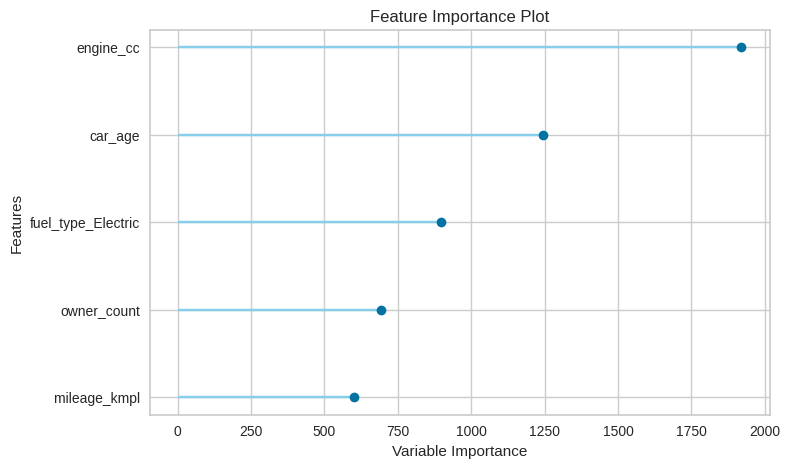

In [ ]:
# Feature Importances Plot

plot_model(best, plot='feature')

In [ ]:
# Coefficients

lr_model = create_model("lr")
coefficients = lr_model.coef_
print(coefficients)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,811.7976,1050357.7096,1024.8696,0.8730,0.1865,0.1425
1,803.5551,1019561.8326,1009.7335,0.8715,0.1876,0.1407
2,803.5689,1010784.1625,1005.3776,0.8661,0.1729,0.1308
3,783.0284,989652.9662,994.8130,0.8677,0.1920,0.1421
4,744.8044,873515.5259,934.6205,0.8835,0.1810,0.1312
5,788.3805,960829.2675,980.2190,0.8676,0.1723,0.1327
6,811.8356,1033248.3920,1016.4883,0.8699,0.2017,0.1475
7,811.5376,1026749.5540,1013.2865,0.8692,0.1944,0.1479
8,854.5761,1155412.8860,1074.9013,0.8662,0.2017,0.1540


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

[  599.12434777  1920.22723462  -691.64528678 -1245.4354321
   898.03738166]


In [ ]:
# Get the actual transformed feature names
feature_names = get_config("X_train_transformed").columns


coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

print(coef_df.sort_values(by='Coefficient', ascending=False))


              Feature  Coefficient
1           engine_cc  1920.227235
4  fuel_type_Electric   898.037382
0        mileage_kmpl   599.124348
2         owner_count  -691.645287
3             car_age -1245.435432
